In [46]:
#This is a python project using asos dataset(products_asos.csv)
#By: Mathew Kemboi

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    'products_asos.csv',
    engine='python',
    on_bad_lines='skip'
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f"Data Loaded: {len(df)} rows")
df.head()

Data Loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [18]:
#We are going to check for missed opportunities at ASOS
#We are going to audit ASOS Supply chain
#See how much money they are losing BECAUSE THEY CANNOT KEEP THEIR best products and stock
#We will use the description column
#make sure description column is a string using the following command
df['description'] = df['description'].astype(str)

# Text splitting
def get_brand(text):
    if 'by ' in text:
        try:
            return text.split('by ')[1].split(' ')[0]
        except:
            return "Unknown"
    return "Unknown"

df['brand_raw'] = df['description'].apply(get_brand)

df


,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket
...,...,...,...,...,...,...,...,...,...,...
30840,https://www.asos.com/urban-revivo/urban-revivo...,Urban Revivo square neck mini dress in floral ...,"XS - UK 6 - Out of stock,S - UK 8 - Out of sto...",Urban Revivo square neck mini dress in floral ...,44.00,Multi,116745746.0,[{'Product Details': 'Mini dress by Urban Revi...,['https://images.asos-media.com/products/urban...,Urban
30841,https://www.asos.com/asos-design/asos-design-l...,ASOS DESIGN long sleeve maxi t-shirt dress in ...,"UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...",ASOS DESIGN long sleeve maxi t-shirt dress in ...,24.00,Black,1444255.0,[{'Product Details': 'Dress by ASOS DESIGN Act...,['https://images.asos-media.com/products/asos-...,ASOS
30842,https://www.asos.com/asyou/asyou-layered-t-shi...,ASYOU layered t-shirt dress with focus graphic...,"UK 4 - Out of stock,UK 6,UK 8 - Out of stock,U...",ASYOU layered t-shirt dress with focus graphic...,22.99,Washed black,110783769.0,[{'Product Details': 'Dress by ASYOU Exclusive...,['https://images.asos-media.com/products/asyou...,ASYOU
30843,https://www.asos.com/miss-selfridge/miss-selfr...,Miss Selfridge Petite rib knit frill hem funne...,"UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...",Miss Selfridge Petite rib knit frill hem funne...,32.99,BLACK,116363729.0,[{'Product Details': 'Petite by Miss Selfridge...,['https://images.asos-media.com/products/miss-...,Miss


In [19]:
#check for unique values
df['brand_raw'].unique()

array(['New', 'StradivariusJacket', 'JDYLow-key', ..., 'DesignB',
       'YoursTreat', 'YoursWash,'], dtype=object)

The results from the unique command shows that the brands are not clean.Many are broken or incomplete(Split or truncated brands like New,River,Miss,Under,In,The,Basic,and Simply).There is also an issue of Corrupted brand + product text merged i.e StradivariusJacket instead of Stradivarius.Marketing tags are also mixed into brands(Low-key,Throw-on,Mid-season,Stand and That, Exclusive) making the dataset very noisy.Punctuation or formatting is also another problem for instance MangoBrb,
BershkaThat, StradivariusCompliments:


In [20]:
df.head(5)

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket


In [21]:
#Inspecting the Value counts
df['brand_raw'].value_counts()

,count
brand_raw,
ASOS,4844
TopshopWelcome,711
New,511
River,467
Miss,429
...,...
SelectedThat,1
adidasCan't,1
KickersPart,1


Are these real brands?YES, ASOS,Nike,Topshop,and Puma are real brands but New,River,Miss,Vero and Tommy are likely incomplete.They could be New Look,River Island,Miss Selfridge,Vero Moda,Tommy Hilfiger.Brands are also mixed with marketing text i.e TopshopWelcome,WeekdayThrow,MonkiCompliments: and NikePadded.If "The" appears 70 times, that is a huge warning sign.

A clothing website will not have 70 products from a brand called "The".

That means your extraction logic is capturing ordinary words as brands.

In [22]:
#Case inconsistency check
df['brand_raw'].str.lower().value_counts()

,count
brand_raw,
asos,4844
topshopwelcome,711
new,511
river,467
miss,429
...,...
help,1
weekdaylaid-back,1
pimkiefor,1


In [23]:
brand_map = {

'New': 'New Look',
'River': 'River Island',
'Miss': 'Miss Selfridge',
'TopshopWelcome': 'Topshop'
}
df['Brand']=df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts [brand_counts >5]. index
df_clean =df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


In [24]:
df.head(10)

,url,name,size,category,price,color,sku,description,images,brand_raw,Brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,New Look
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,New Look
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,New Look
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New,New Look
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket,StradivariusJacket
5,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket,StradivariusJacket
6,https://www.asos.com/barneys-originals/barneys...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket,StradivariusJacket
7,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket,StradivariusJacket
8,https://www.asos.com/asos-petite/asos-design-p...,JDY oversized trench coat in stone,"3XL - UK 18 - Out of stock,XS - UK 6,S - UK 8,...",JDY oversized trench coat in stone,45.00,STONE,125806824.0,[{'Product Details': 'Coats & Jackets by JDYLo...,['https://images.asos-media.com/products/jdy-o...,JDYLow-key,JDYLow-key
9,https://www.asos.com/jdy/jdy-oversized-trench-...,JDY oversized trench coat in stone,"3XL - UK 18 - Out of stock,XS - UK 6,S - UK 8,...",JDY oversized trench coat in stone,45.00,STONE,125806824.0,[{'Product Details': 'Coats & Jackets by JDYLo...,['https://images.asos-media.com/products/jdy-o...,JDYLow-key,JDYLow-key


In [25]:
#Pattern / structure check
df['brand_raw'].str.contains(' ', na=False).value_counts()

,count
brand_raw,
False,18378


None of the 18378 values in brand_raw contain a space.The extracted brand field contains only single-word values. Multi-word brands have likely been truncated during extraction.This is why we are seeing values like: New ,River,Vero
and  Tommy.

In [32]:
# Function to analyze stockouts
def calculate_phantom_revenue(size_str):#Defining calculate_phantom_revenue function
#Input size_str contains size and stock information.

    if not isinstance(size_str, str):
        return 0, 0.0

    # Split "UK 6, UK 8 - Out of stock" into list
    sizes = size_str.split(',')

    total_sizes = len(sizes)

    # Count how many items are out of stock
    out_of_stock_count = size_str.count('Out of stock')

    # Calculate Rate (0.0 to 1.0)
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

    return out_of_stock_count, rate

metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

df_clean['Stockout_Count'] = [x[0] for x in metrics]
df_clean['Stockout_Ratesd'] = [x[1] for x in metrics]

df_clean['Lost_Revenue'] = df_clean['price'] * df_clean['Stockout_Count']

cols = ['Brand', 'name', 'price', 'Stockout_Count', 'Lost_Revenue']
print(df_clean.sort_values(by='Lost_Revenue', ascending=False).head(5) [cols])

         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_Count  Lost_Revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


-Most of inventory clustered in low price and demand(SAFE area but low growth)
-The red line reveal outlier
Top right quadrant shows customers are willing to buy at a higher and sell out faster.

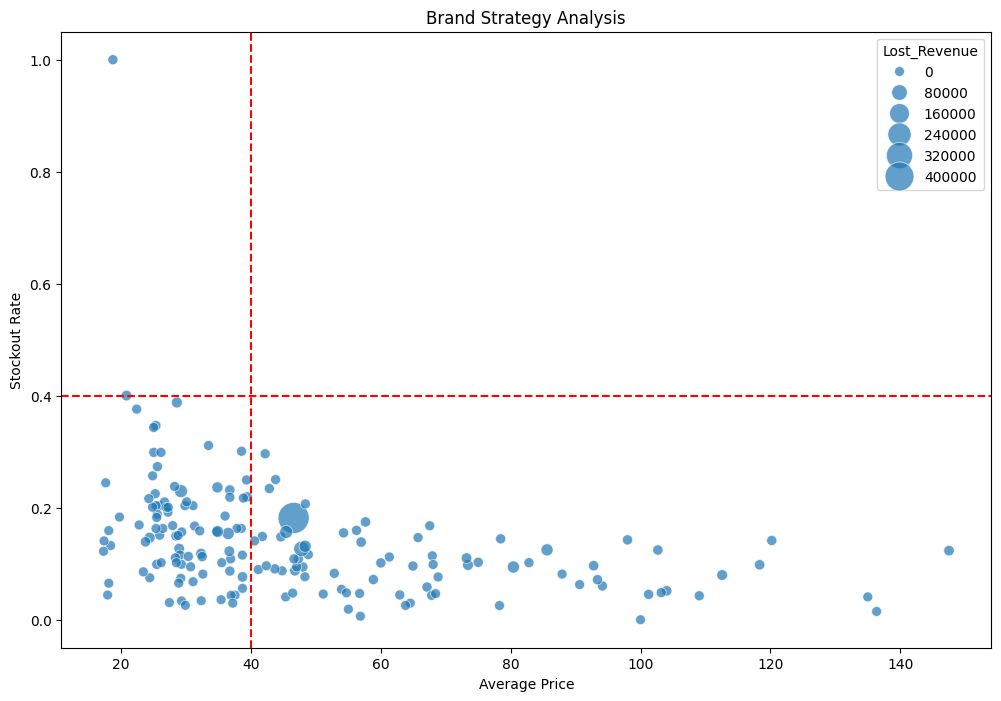

In [45]:
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Count': 'mean',
    'Lost_Revenue': 'sum',
    'name': 'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize=(12, 8))

#Stockout_Rate
brand_strategy['Stockout_Rate'] = (
    brand_strategy['Stockout_Count'] /
    brand_strategy['Stockout_Count'].max()
)
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    size='Lost_Revenue',
    sizes=(50, 500),
    alpha=0.7
)

winners = brand_strategy[
    (brand_strategy['price'] > 40) &
    (brand_strategy['Stockout_Rate'] > 0.4)
]

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price'] + 1,
        winners.iloc[i]['Stockout_Rate'],
        winners.iloc[i]['Brand']
    )

plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')

plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')

plt.show()

**Recommendations**

Based on the relationship between price, stockouts, and estimated revenue loss, the following actions are recommended:

1. Prioritise mid-priced brands (£25–£60)

This segment shows the highest concentration of stockout risk and revenue leakage.

Improve demand forecasting using historical sales and seasonality
Shorten replenishment cycles for high-performing SKUs
Introduce dynamic safety stock levels based on sales velocity
Monitor this segment as a primary performance KPI rather than treating it as a mid-priority category
2. Strengthen fast-mover replenishment for low-priced items

Low-priced products with high stockout rates indicate rapid sell-through.

Implement automatic reorder triggers based on sales velocity
Maintain minimum safety stock for high-demand SKUs
Use weekly or even daily restock reviews for fast-moving items
Identify “frequent stockout” SKUs and treat them separately from standard inventory rules
3. Improve availability discipline for high-value products (>£40)

Although stockout rates are lower in premium segments, the revenue impact per unit is higher.

Enforce stricter stock continuity rules for high-price items
Use SKU-level forecasting instead of aggregated brand-level planning
Prevent complete stockouts through proactive replenishment thresholds
Prioritise availability consistency over inventory minimisation
4. Move towards size-level inventory management

A significant portion of stockouts is likely driven by size or variant imbalance rather than full product depletion.

Track stock performance at size level (e.g., UK 6, 8, 10)
Identify high-demand sizes per brand and adjust allocation accordingly
Rebalance inventory distribution across sizes based on sales patterns
Reduce overstock in low-demand sizes while protecting high-demand ones
5. Introduce a high-risk monitoring system

Certain combinations of price and stockout rate signal elevated revenue risk.

Flag brands where price > £40 and stockout rate > 0.4
Create a weekly “at-risk brands” report for supply chain review
Investigate root causes (supplier delays, demand spikes, poor forecasting)
Assign ownership for resolution of flagged SKUs
6. Build predictive stockout alerts

Move from reactive to proactive inventory management.

Develop rule-based alerts such as:
Stockout rate > 0.3 AND high revenue contribution
Incorporate lead time and demand variability into alert thresholds
Use alerts to trigger pre-emptive replenishment actions
Track avoided stockouts as a performance metric
7. Reframe inventory KPIs around revenue risk, not just stock levels

Traditional stock metrics may not capture commercial impact.

Track “lost revenue due to stockouts” as a core KPI
Prioritise SKUs based on revenue exposure, not just unit movement
Segment reporting by price band and demand intensity
Align inventory decisions with revenue protection rather than stock efficiency alone